In [ ]:
## chạy để reset lại kết quả
survey_results = []

MLEM    | RMSE nhỏ nhất: vòng 16 | RMSE = 10.87371
MAP-MRP | RMSE nhỏ nhất: vòng 44 | RMSE = 8.01475


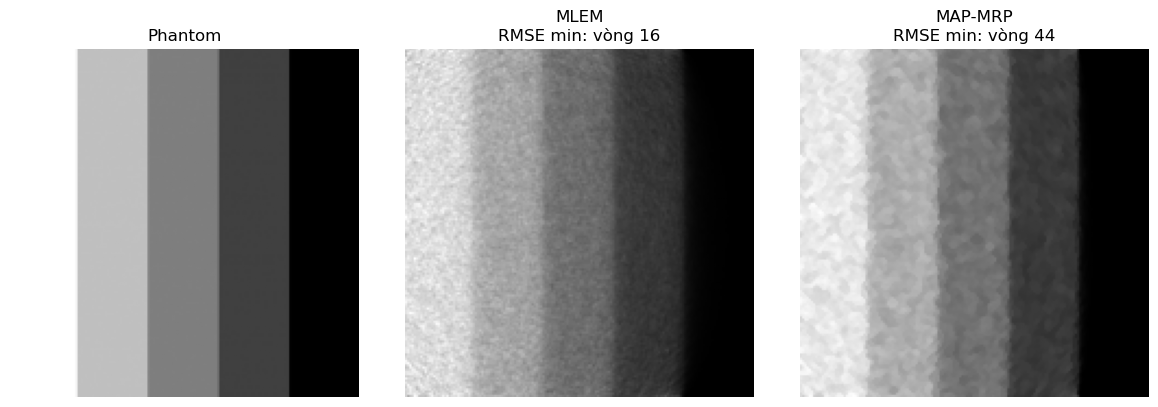

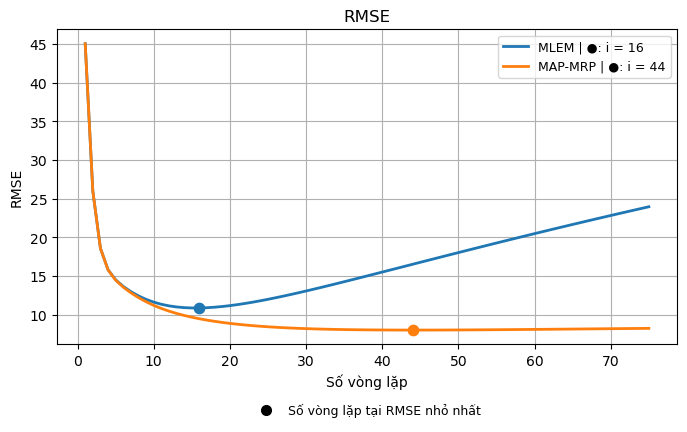

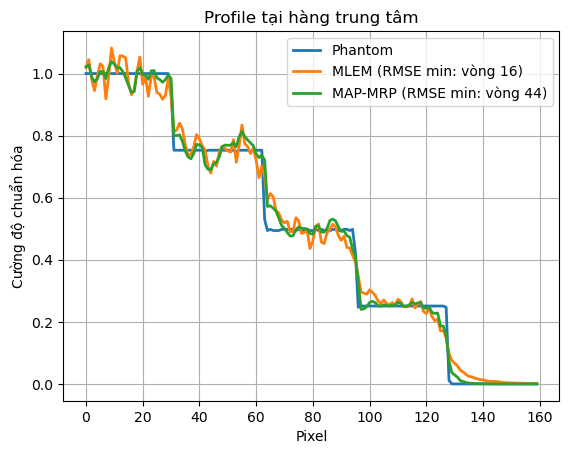

In [38]:
## Tái tạo MLEM và MAP-MRP, khảo sát RMSE và Profile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import median_filter
from skimage import io, data_dir
from skimage.transform import radon, iradon
import os
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
# ==================== Thông số =====================
np.random.seed(0)
niter = 75
counts = int(1e7)
beta = 0.3
eps = 1e-6

# ===================== Phantom =====================
phantom_path = os.path.join(data_dir, "phantombacthang160.png")
image = io.imread(phantom_path, as_gray=True).astype(np.float32)
theta = np.arange(0, 180, 1)

# ===================== Phép chiếu =====================
sinogram = radon(image, theta, circle=False)
total = sinogram.sum()
measured = np.random.poisson(sinogram / total * counts).astype(np.float32)
measured *= total / counts
sensitivity = np.maximum(iradon(np.ones_like(measured), theta, filter_name=None, circle=False), eps)

# ===================== Hàm tái tạo =====================
def reconstruct(method="MLEM"):
    x = np.ones_like(image)
    rmse, psnr, ssim = [], [], []
    best_rmse, best_iter, best_img = np.inf, 0, None

    for k in range(niter):
        proj = radon(x, theta, circle=False)
        ratio = measured / (proj + eps)
        back = iradon(ratio, theta, filter_name=None, circle=False)
        update = np.maximum(x * back / sensitivity, eps)

        if method.upper() == "MRP":
            med = median_filter(x, size=3, mode="reflect")
            penalty = np.maximum(1 + beta * (x - med) / (med + eps), eps)
            x = update / penalty
        else:
            x = update

        x = np.maximum(x, eps)
        e = np.sqrt(np.mean((image - x)**2))
        rmse.append(e)
        psnr.append(peak_signal_noise_ratio(image, x, data_range=image.max()-image.min()))
        ssim.append(structural_similarity(image, x, data_range=image.max()-image.min()))

        if e < best_rmse:
            best_rmse, best_iter, best_img = e, k + 1, x.copy()

    return {"image": best_img, "rmse": rmse, "psnr": psnr, "ssim": ssim, "best_iter": best_iter, "best_rmse": best_rmse}

# ===================== Tái tạo =====================
mlem = reconstruct("MLEM")
mrp = reconstruct("MRP")

print(f'MLEM    | RMSE nhỏ nhất: vòng {mlem["best_iter"]} | RMSE = {mlem["best_rmse"]:.5f}')
print(f'MAP-MRP | RMSE nhỏ nhất: vòng {mrp["best_iter"]} | RMSE = {mrp["best_rmse"]:.5f}')

# ===================== Ảnh tái tạo =====================
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image, cmap="gray"); ax[0].set_title("Phantom")
ax[1].imshow(mlem["image"], cmap="gray"); ax[1].set_title(f'MLEM\nRMSE min: vòng {mlem["best_iter"]}')
ax[2].imshow(mrp["image"], cmap="gray"); ax[2].set_title(f'MAP-MRP\nRMSE min: vòng {mrp["best_iter"]}')
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

# ===================== RMSE =====================
iteration = np.arange(1, niter + 1)
fig, ax = plt.subplots(figsize=(8, 5))

line_mlem, = ax.plot(iteration, mlem["rmse"], lw=2)
color_mlem = line_mlem.get_color()
line_mrp, = ax.plot(iteration, mrp["rmse"], lw=2)
color_mrp = line_mrp.get_color()

# ● RMSE nhỏ nhất
ax.scatter(mlem["best_iter"], mlem["best_rmse"], s=55, color=color_mlem, zorder=5)
ax.scatter(mrp["best_iter"], mrp["best_rmse"], s=55, color=color_mrp, zorder=5)

# Ghi chú 1 - bên trong đồ thị
label_mlem = f'MLEM | ●: i = {mlem["best_iter"]}'
label_mrp = f'MAP-MRP | ●: i = {mrp["best_iter"]}'
legend1 = ax.legend([line_mlem, line_mrp], [label_mlem, label_mrp], loc="upper right", fontsize=9)
ax.add_artist(legend1)

ax.set_title("RMSE")
ax.set_xlabel("Số vòng lặp")
ax.set_ylabel("RMSE")
ax.grid(True)

# Ghi chú 2 - bên dưới đồ thị
handle_min = Line2D([0], [0], marker="o", linestyle="None",
                    markerfacecolor="black", markeredgecolor="black", markersize=7)

ax.legend([handle_min], ["Số vòng lặp tại RMSE nhỏ nhất"],
          loc="upper center", bbox_to_anchor=(0.5, -0.15), frameon=False, fontsize=9)

plt.subplots_adjust(bottom=0.25)
plt.show()

# ===================== Profile =====================
center = image.shape[0] // 2
phantom_min = image.min()
phantom_range = image.max() - image.min()

def get_profile(img):
    return (img[center, :] - phantom_min) / phantom_range
profile_true = get_profile(image)
profile_mlem = get_profile(mlem["image"])
profile_mrp = get_profile(mrp["image"])

plt.figure()
plt.plot(profile_true, lw=2, label="Phantom")
plt.plot(profile_mlem, lw=2, label=f'MLEM (RMSE min: vòng {mlem["best_iter"]})')
plt.plot(profile_mrp, lw=2, label=f'MAP-MRP (RMSE min: vòng {mrp["best_iter"]})')
plt.title("Profile tại hàng trung tâm")
plt.xlabel("Pixel")
plt.ylabel("Cường độ chuẩn hóa")
plt.grid(True)
plt.legend()
plt.show()

# ==================== Lưu kết quả khảo sát ====================
if "survey_results" not in globals():
    survey_results = []

result = {
    "count": counts,
    "label": {int(5e5): "5e5", int(1e6): "1e6", int(5e6): "5e6", int(1e7): "1e7"}[counts],
    "mlem_rmse": mlem["rmse"],
    "mlem_psnr": mlem["psnr"],
    "mlem_ssim": mlem["ssim"],
    "mrp_rmse": mrp["rmse"],
    "mrp_psnr": mrp["psnr"],
    "mrp_ssim": mrp["ssim"],
    "mlem_best_iter": mlem["best_iter"],
    "mrp_best_iter": mrp["best_iter"]
}
survey_results = [r for r in survey_results if r["count"] != counts]
survey_results.append(result)

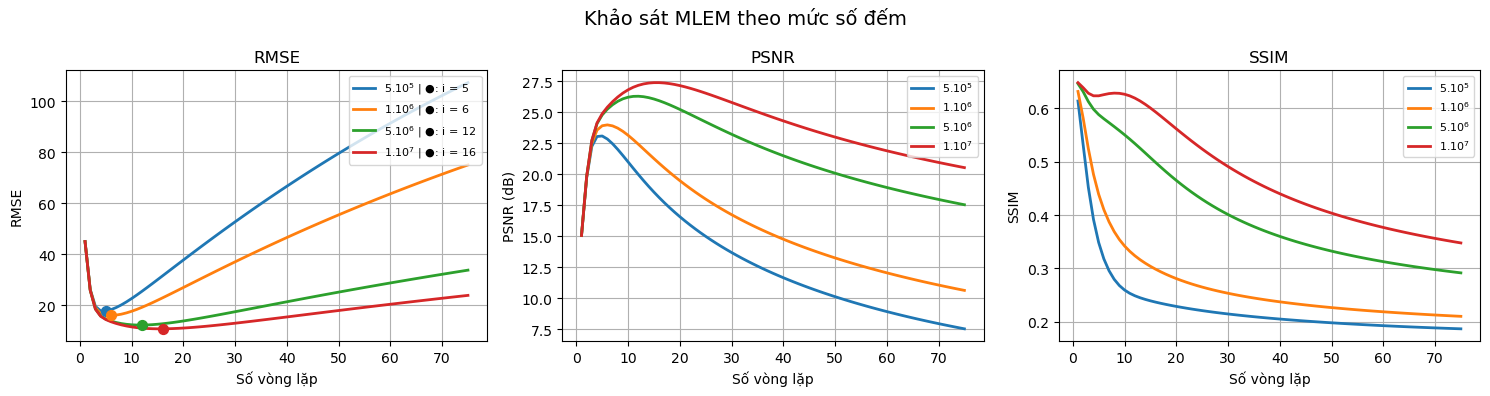

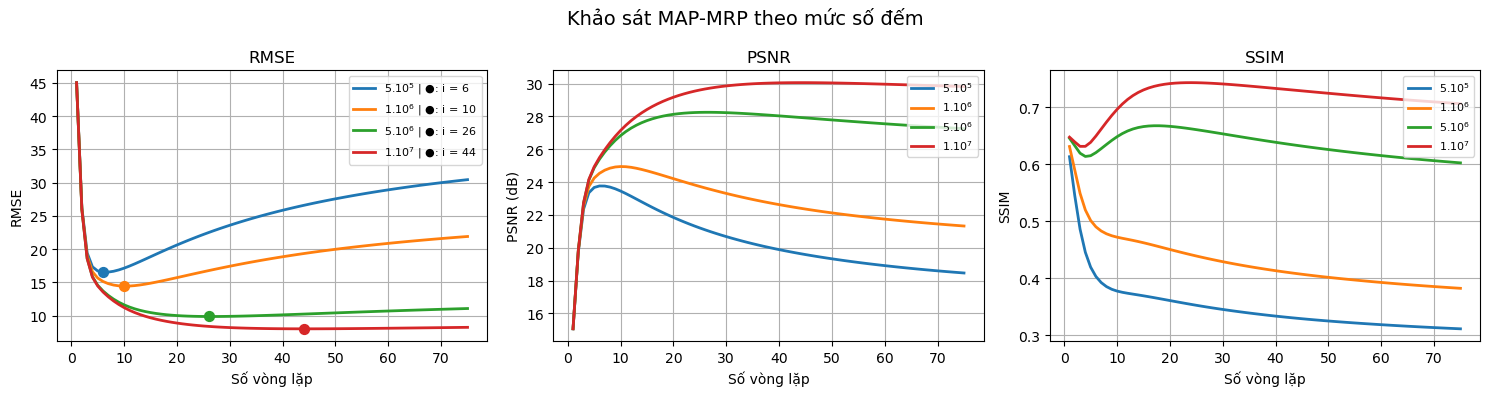

In [37]:
# ===================== cập nhật đồ thị RMSE, PSNR, SSIM sau mỗi lần chạy =====================
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

label_map = {
    int(5e5): r"$5.10^5$",
    int(1e6): r"$1.10^6$",
    int(5e6): r"$5.10^6$",
    int(1e7): r"$1.10^7$"
}

def plot_metrics(method="MLEM"):
    results = sorted(survey_results, key=lambda r: r["count"])
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    colors = []

    # ===================== RMSE =====================
    for r in results:
        rmse = r["mlem_rmse"] if method == "MLEM" else r["mrp_rmse"]
        best = r["mlem_best_iter"] if method == "MLEM" else r["mrp_best_iter"]
        line, = ax[0].plot(np.arange(1, len(rmse)+1), rmse, lw=2)
        color = line.get_color()
        colors.append(color)
        ax[0].scatter(best, rmse[best-1], s=50, color=color, zorder=5)

    handles = [Line2D([0], [0], color=c, lw=2) for c in colors]
    legend_labels = [
        f'{label_map[r["count"]]} | ●: i = {r["mlem_best_iter"] if method == "MLEM" else r["mrp_best_iter"]}'
        for r in results
    ]

    ax[0].legend(handles, legend_labels, loc="upper right", fontsize=8)
    ax[0].set_title("RMSE")
    ax[0].set_xlabel("Số vòng lặp")
    ax[0].set_ylabel("RMSE")
    ax[0].grid(True)

    # ===================== PSNR =====================
    for r, color in zip(results, colors):
        psnr = r["mlem_psnr"] if method == "MLEM" else r["mrp_psnr"]
        ax[1].plot(np.arange(1, len(psnr)+1), psnr, lw=2, color=color)

    ax[1].set_title("PSNR")
    ax[1].set_xlabel("Số vòng lặp")
    ax[1].set_ylabel("PSNR (dB)")
    ax[1].grid(True)
    ax[1].legend(handles, [label_map[r["count"]] for r in results],
                 loc="upper right", fontsize=8)

    # ===================== SSIM =====================
    for r, color in zip(results, colors):
        ssim = r["mlem_ssim"] if method == "MLEM" else r["mrp_ssim"]
        ax[2].plot(np.arange(1, len(ssim)+1), ssim, lw=2, color=color)

    ax[2].set_title("SSIM")
    ax[2].set_xlabel("Số vòng lặp")
    ax[2].set_ylabel("SSIM")
    ax[2].grid(True)
    ax[2].legend(handles, [label_map[r["count"]] for r in results],
                 loc="upper right", fontsize=8)

    fig.suptitle(f"Khảo sát {method} theo mức số đếm", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_metrics("MLEM")
plot_metrics("MAP-MRP")